# Exploring `time_resolved/` (raw per-trial activity)

One `.npz` per model, named `<model_type>_seed<NN>.npz`. This is the raw, **per-trial, time-resolved** hidden activity behind the PSTH/grid figures; `figure_data.pkl['aligned_mean']` is just its per-unit average.

The demo figure below uses the shared style sheet (`code/figure_style.mplstyle`) and the stimulus colours from `code/figure_config.py`.

In [1]:
%matplotlib inline
import numpy as np, json
import sys
from pathlib import Path
def _find(rel):
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / rel).exists():
            return c / rel
    raise FileNotFoundError(rel + " (run from inside the bundle)")
CODE = _find("code"); DATA = _find("figure_data")
sys.path.insert(0, str(CODE))
import matplotlib.pyplot as plt
plt.style.use(str(CODE / 'figure_style.mplstyle'))      # shared style
from figure_config import STIM_COLORS                    # agreed stim colours

files = sorted((DATA / 'time_resolved').glob('*.npz'))
print(len(files), 'files, e.g.:', [f.name for f in files[:3]])
# prefer a fully-trained classif_rl file for the demo, else the first available
pick = next((f for f in files if f.name.startswith('classif_rl_seed')), files[0])
z = np.load(pick, allow_pickle=True)
print('\nloaded', pick.name)
print('keys:', list(z.keys()))

3 files, e.g.: ['classif_rl_readout_only_seed42.npz', 'classif_rl_readout_only_seed43.npz', 'classif_rl_seed42.npz']

loaded classif_rl_seed42.npz
keys: ['aligned', 'stimulus', 'vigour', 'bounds', 'segment_labels', 'stim_labels', 'meta']


## Contents
- `aligned` — `(trial, time, unit)` hidden activity in the aligned window.
- `stimulus` — `(trial,)` stimulus id (0/1/2 = 0%/50%/100%).
- `vigour` — `(trial,)` reward-window mean vigour.
- `bounds` — `[n_iti_pre, stim_ts, rew_ts]`; `segment_labels`, `stim_labels`.

In [2]:
print('aligned :', z['aligned'].shape, '= (trial, time, unit)')
print('stimulus:', z['stimulus'].shape, '| trials per stim:', np.bincount(z['stimulus']))
print('vigour  :', z['vigour'].shape)
print('bounds  :', z['bounds'], '| segments:', list(z['segment_labels']))
print('meta    :', json.loads(str(z['meta'])))

aligned : (1600, 11, 128) = (trial, time, unit)
stimulus: (1600,) | trials per stim: [536 536 528]
vigour  : (1600,)
bounds  : [3 5 3] | segments: ['ITI', 'stim', 'outcome']
meta    : {'model_type': 'classif_rl', 'seed': 42, 'dims_aligned': ['trial', 'time', 'unit']}


## Demo — recompute a population PSTH per stimulus from the raw trials
Uses the style sheet and the `STIM_COLORS` from the figure config; dotted lines mark the ITI|stim and stim|outcome boundaries.

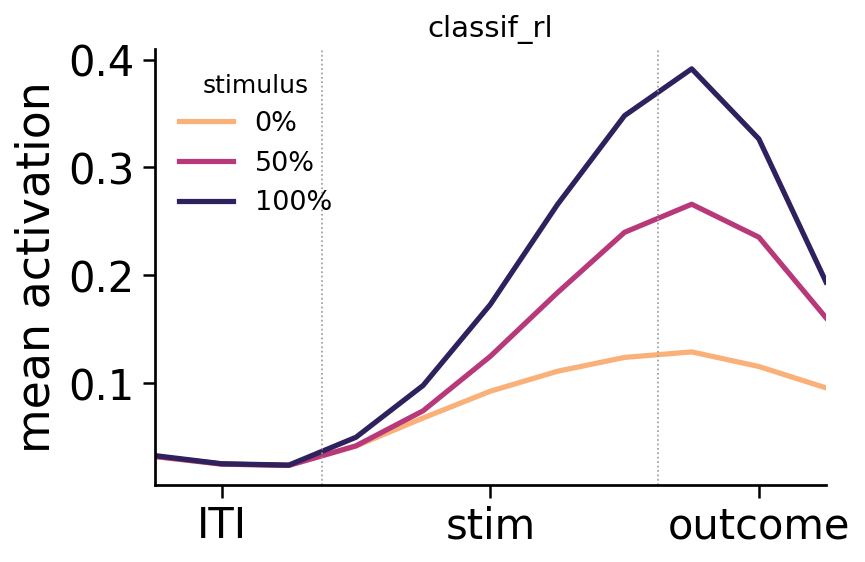

In [3]:
al = z['aligned']; stim = z['stimulus']
n_iti, stim_ts, rew_ts = (int(b) for b in z['bounds']); n_t = al.shape[1]; x = np.arange(n_t)
fig, ax = plt.subplots(figsize=(6, 4))
for s, lab in enumerate(z['stim_labels']):
    psth = al[stim == s].mean((0, 2))      # mean over trials & units -> (time,)
    ax.plot(x, psth, color=STIM_COLORS[s], lw=2.5, label=str(lab))
ax.axvline(n_iti - 0.5, color='0.6', lw=0.8, ls=':')
ax.axvline(n_iti + stim_ts - 0.5, color='0.6', lw=0.8, ls=':')
ax.set_xlim(0, n_t - 1); ax.margins(x=0)
ax.set_xticks([n_iti/2 - 0.5, n_iti + stim_ts/2 - 0.5, n_iti + stim_ts + rew_ts/2 - 0.5])
ax.set_xticklabels(list(z['segment_labels']))
ax.set_ylabel('mean activation')
ax.legend(title='stimulus', fontsize=13, title_fontsize=12)
ax.set_title(json.loads(str(z['meta']))['model_type'])
fig.tight_layout(); plt.show()

## Demo — heatmap of per-unit activity over time
Trial-averaged activity for each unit across the aligned window, one panel per presented stimulus (units sorted by preferred stimulus); same `hot` colour map as the figure heatmaps, shared scale across the three panels.

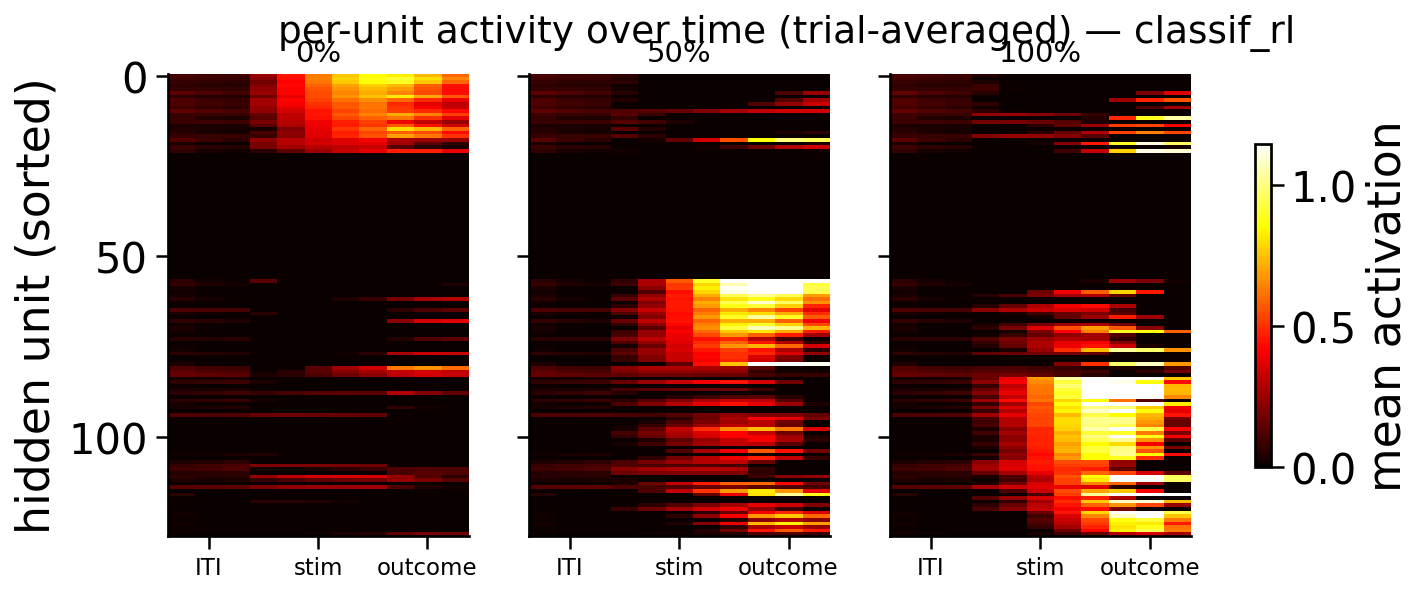

In [4]:
al = z['aligned']; stim = z['stimulus']
n_iti, stim_ts, rew_ts = (int(b) for b in z['bounds'])
mean_by_stim = np.stack([al[stim == s].mean(0) for s in range(3)])   # (stim, time, unit)
sw = mean_by_stim[:, n_iti:n_iti + stim_ts, :].mean(1)               # (stim, unit) stim window
peak = sw.max(0); pref = sw.argmax(0); order = np.lexsort((-peak, pref))
vmax = float(np.percentile(mean_by_stim, 99))
xt = [n_iti/2 - 0.5, n_iti + stim_ts/2 - 0.5, n_iti + stim_ts + rew_ts/2 - 0.5]
fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True)
for s, ax in enumerate(axes):
    im = ax.imshow(mean_by_stim[s][:, order].T, aspect='auto', cmap='hot', vmin=0, vmax=vmax)
    ax.set_title(str(z['stim_labels'][s]), fontsize=14)
    ax.set_xticks(xt); ax.set_xticklabels(list(z['segment_labels']), fontsize=11)
    if s == 0: ax.set_ylabel('hidden unit (sorted)')
fig.colorbar(im, ax=axes, shrink=0.7, label='mean activation')
fig.suptitle('per-unit activity over time (trial-averaged) — ' + json.loads(str(z['meta']))['model_type'])
plt.show()